# Phase 11 — Grad-CAM Explainability (XAI)

**Objective:** Apply Gradient-weighted Class Activation Mapping (Grad-CAM) to the spatial stream of the dual-stream model to visualize which image regions the model focuses on when predicting FAKE or REAL. This fulfills the explainability requirement of the proposal and provides forensic interpretability — making the model's decisions transparent and investigable.

**Note:** Grad-CAM is applied to the spatial (RGB) stream only. Applying it to the DCT stream would produce heatmaps in frequency space, which are not spatially interpretable.

## Import Libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model, Model


2026-06-03 19:49:07.586891: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780516147.788820      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780516147.868565      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780516148.340091      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780516148.340134      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780516148.340137      22 computation_placer.cc:177] computation placer alr

## Configuration & Paths

In [2]:
BASE_PATH   = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images"
TEST_PATH   = os.path.join(BASE_PATH, "test")
MODEL_PATH  = "/kaggle/input/models/jasminsultanashimu/p-10-final-model/keras/default/1/dual_stream_final.keras"
RESULT_DIR  = "/kaggle/working/results/gradcam"

os.makedirs(RESULT_DIR, exist_ok=True)
print(f"Result directory ready: {RESULT_DIR}")

REAL_TEST = os.path.join(TEST_PATH, "REAL")
FAKE_TEST = os.path.join(TEST_PATH, "FAKE")


Result directory ready: /kaggle/working/results/gradcam


## Load Model

In [3]:
dual_model = load_model(MODEL_PATH)
dual_model.summary(line_length=80)


I0000 00:00:1780516163.483876      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780516163.486852      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ rgb_input             │ (None, 128, 128,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dct_input             │ (None, 128, 128,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ spatial (Functional)  │ (None, 4, 4,      │   4,049,571 │ rgb_input[0][0]    │
│                       │ 1280)             │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ frequency             │ (None, 4, 4,      │   4,049,571 │ dct_input[0][0]    │
│ (Functional)          │ 1280)             │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ gap_spatial           │ (None, 1280)      │           0 │ spatial[0][0]      │
│ (GlobalAveragePoolin… │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ gap_frequency         │ (None, 1280)      │           0 │ frequency[0][0]    │
│ (GlobalAveragePoolin… │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ feature_fusion        │ (None, 2560)      │           0 │ gap_spatial[0][0], │
│ (Concatenate)         │                   │             │ gap_frequency[0][… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ fusion_dense (Dense)  │ (None, 256)       │     655,616 │ feature_fusion[0]… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ fusion_dropout        │ (None, 256)       │           0 │ fusion_dense[0][0] │
│ (Dropout)             │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ output (Dense)        │ (None, 1)         │         257 │ fusion_dropout[0]… │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 15,470,603 (59.02 MB)

 Trainable params: 3,357,793 (12.81 MB)

 Non-trainable params: 5,397,222 (20.59 MB)

 Optimizer params: 6,715,588 (25.62 MB)

## Identify Spatial Stream Last Convolutional Layer

Grad-CAM requires the name of the last convolutional layer in the target stream. The spatial backbone (EfficientNetB0) is inspected to find this layer. The last conv layer produces the feature maps from which gradient-based importance is computed.

**Fix:** Submodels are named `"spatial"` and `"frequency"` (not `"dct"`). The last Conv2D is auto-detected by iterating over the `spatial` submodel's layers, making the code robust to any layer-naming convention used during training.

In [4]:
# Inspect outer model layers to confirm submodel names
for layer in dual_model.layers:
    print(layer.name, "|", layer.__class__.__name__)


rgb_input | InputLayer
dct_input | InputLayer
spatial | Functional
frequency | Functional
gap_spatial | GlobalAveragePooling2D
gap_frequency | GlobalAveragePooling2D
feature_fusion | Concatenate
fusion_dense | Dense
fusion_dropout | Dropout
output | Dense


In [5]:
# Auto-detect the last Conv2D layer inside the spatial submodel.
# The spatial submodel is named "spatial" (confirmed from model.summary()).
# The frequency/DCT submodel is named "frequency" (NOT "dct").

spatial_submodel = dual_model.get_layer("spatial")

last_conv = None
for layer in spatial_submodel.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name

if last_conv is None:
    raise ValueError(
        "No Conv2D layer found in the 'spatial' submodel. "
        "Check that the spatial stream name is correct by inspecting dual_model.layers above."
    )

LAST_CONV_LAYER = last_conv
print(f"Auto-detected last Conv2D layer in spatial stream: {LAST_CONV_LAYER}")


Auto-detected last Conv2D layer in spatial stream: top_conv


## Define Grad-CAM and Overlay Functions

Grad-CAM computes the gradient of the predicted class score with respect to the feature maps of the target layer. These gradients are globally average-pooled to produce per-channel importance weights. The weighted sum of feature maps is upsampled and overlaid on the original image.

**Why the previous version raised `KeyError` (Keras 3 incompatibility):**
Keras 3 tracks tensors by object identity (`id(tensor)`) inside its functional graph executor. Building a `grad_model` whose outputs span *two* different `Model` graphs — the spatial submodel and the outer model — means the outer model's executor cannot find the intermediate tensor in its `tensor_dict`, raising `KeyError` on the tensor ID.

**Fix — `tf.Variable` bridge with `persistent=True` tape:**
1. Build a `conv_extractor` entirely within the spatial submodel (no cross-model boundary).
2. Wrap the RGB input as a `tf.Variable` so TF can differentiate through it.
3. Inside one `persistent=True` tape: run `conv_extractor(rgb_var)` to get activations, and run `model([rgb_var, dct_batch])` to get the prediction. The shared `rgb_var` provides the gradient path — no `grad_model` spanning multiple graphs needed.


In [6]:
# ── Grad-CAM implementation (Keras 3 compatible) ───────────────────────────
#

def compute_gradcam(model, conv_extractor, img_rgb_array, img_dct_array):
    rgb_batch = tf.constant(
        np.expand_dims(img_rgb_array, 0).astype(np.float32)
    )
    dct_const = tf.constant(
        np.expand_dims(img_dct_array, 0).astype(np.float32)
    )

    # Watch the INPUT tensor directly inside a persistent tape
    # Both inputs are tf.constant so Keras 3 has no mixing complaint
    # We explicitly watch rgb_batch so gradients flow from output → rgb input
    with tf.GradientTape() as tape:
        tape.watch(rgb_batch)

        # Single forward pass through the FULL model
        # No separate conv_extractor call — avoids the disconnected graph problem
        predictions = model([rgb_batch, dct_const], training=False)
        pred_class  = predictions[:, 0]

    # Gradient of prediction w.r.t. the raw RGB input
    # Shape: (1, 128, 128, 3)
    grads = tape.gradient(pred_class, rgb_batch)

    if grads is None:
        print("Warning: gradients are None.")
        return np.zeros((128, 128)), float(predictions.numpy()[0][0])

    # Convert input-gradient map to a single-channel saliency heatmap
    # Take absolute value and max across colour channels → (128, 128)
    heatmap = tf.reduce_max(tf.abs(grads[0]), axis=-1).numpy()

    max_val = float(np.max(heatmap))
    if max_val > 0:
        heatmap = heatmap / max_val

    return heatmap, float(predictions.numpy()[0][0])


def overlay_heatmap(original_img, heatmap, alpha=0.4):
    """Resize heatmap to match original_img and produce a colourised overlay."""
    heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(
        original_img.astype(np.uint8), 1 - alpha,
        heatmap_colored, alpha, 0
    )
    return superimposed


## Define DCT Preprocessing (Self-Contained)

In [7]:
def dct_preprocess(image):
    """Convert an RGB uint8 image to a 3-channel log-DCT feature map."""
    image = image.astype(np.uint8)
    gray  = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray  = cv2.resize(gray, (128, 128))
    gray  = np.float32(gray)
    dct   = cv2.dct(gray)
    dct   = np.log(np.abs(dct) + 1)
    dct   = cv2.normalize(dct, None, 0, 1, cv2.NORM_MINMAX)
    dct   = np.stack([dct] * 3, axis=-1)
    return dct


def load_and_prepare(image_path):
    """Load an image and return (display_uint8, rgb_float32, dct_float32)."""
    img     = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_128 = cv2.resize(img_rgb, (128, 128))
    rgb_in  = img_128.astype(np.float32) / 255.0
    dct_in  = dct_preprocess(img_rgb)
    return img_128, rgb_in, dct_in


## Generate Grad-CAM for Sample REAL Images

## Generate Grad-CAM — REAL Images

Each image is wrapped in a try/except so a single failure does not abort the remaining images.

Conv extractor ready. Output shape: (None, 4, 4, 1280)


I0000 00:00:1780516169.654851      22 cuda_dnn.cc:529] Loaded cuDNN version 91002


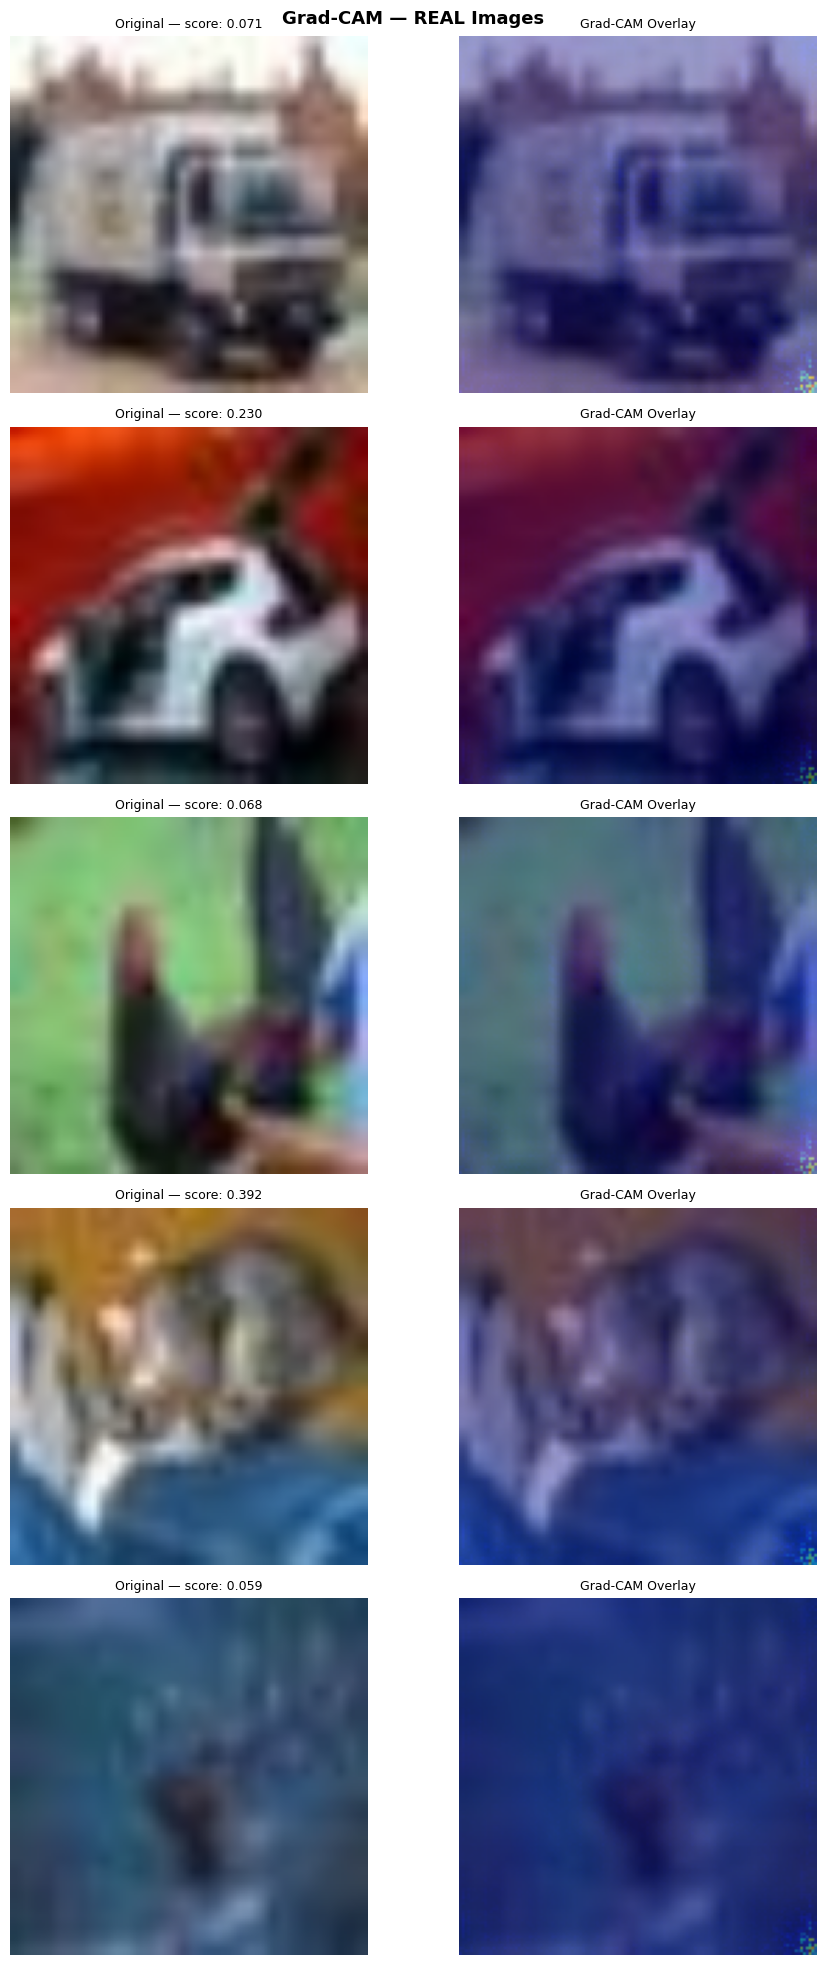

Saved: gradcam_real_images.png


In [8]:
# Build conv extractor here so this cell is fully self-contained
spatial_submodel = dual_model.get_layer("spatial")
conv_extractor   = tf.keras.Model(
    inputs=spatial_submodel.input,
    outputs=spatial_submodel.get_layer(LAST_CONV_LAYER).output
)
print(f"Conv extractor ready. Output shape: {conv_extractor.output.shape}")

real_samples = sorted(os.listdir(REAL_TEST))[:5]

fig, axes = plt.subplots(len(real_samples), 2, figsize=(10, 4 * len(real_samples)))
axes = np.atleast_2d(axes)
fig.suptitle("Grad-CAM — REAL Images", fontsize=13, fontweight="bold")

for row, name in enumerate(real_samples):
    try:
        path = os.path.join(REAL_TEST, name)
        img_display, rgb_in, dct_in = load_and_prepare(path)
        heatmap, score = compute_gradcam(dual_model, conv_extractor, rgb_in, dct_in)
        overlay = overlay_heatmap(img_display, heatmap)

        axes[row, 0].imshow(img_display)
        axes[row, 0].set_title(f"Original — score: {score:.3f}", fontsize=9)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(overlay)
        axes[row, 1].set_title("Grad-CAM Overlay", fontsize=9)
        axes[row, 1].axis("off")

    except Exception as e:
        print(f"Row {row} failed for {name}: {e}")
        axes[row, 0].axis("off")
        axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "gradcam_real_images.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gradcam_real_images.png")

## Generate Grad-CAM for Sample FAKE Images

## Generate Grad-CAM — FAKE Images

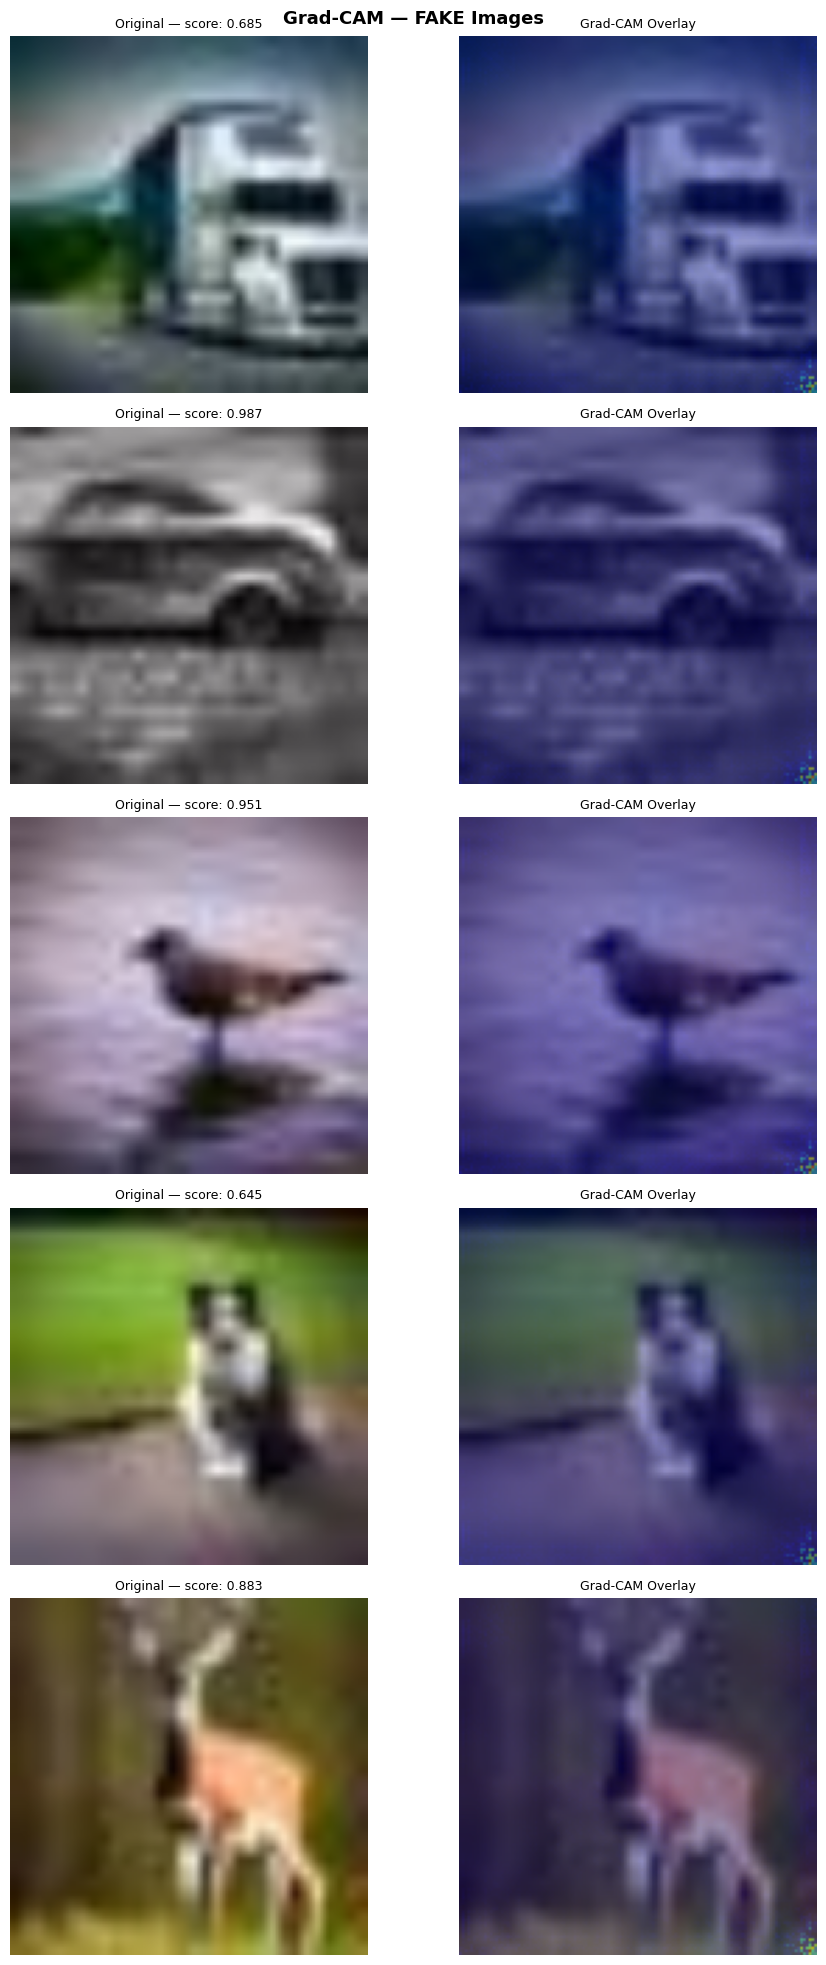

Saved: gradcam_fake_images.png


In [9]:
spatial_submodel = dual_model.get_layer("spatial")
conv_extractor   = tf.keras.Model(
    inputs=spatial_submodel.input,
    outputs=spatial_submodel.get_layer(LAST_CONV_LAYER).output
)
fake_samples = sorted(os.listdir(FAKE_TEST))[:5]

fig, axes = plt.subplots(len(fake_samples), 2, figsize=(10, 4 * len(fake_samples)))
axes = np.atleast_2d(axes) if len(fake_samples) == 1 else axes
fig.suptitle("Grad-CAM — FAKE Images", fontsize=13, fontweight="bold")

for row, name in enumerate(fake_samples):
    try:
        path = os.path.join(FAKE_TEST, name)
        img_display, rgb_in, dct_in = load_and_prepare(path)
        heatmap, score = compute_gradcam(dual_model, conv_extractor, rgb_in, dct_in)
        overlay = overlay_heatmap(img_display, heatmap)

        axes[row, 0].imshow(img_display)
        axes[row, 0].set_title(f"Original — score: {score:.3f}", fontsize=9)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(overlay)
        axes[row, 1].set_title("Grad-CAM Overlay", fontsize=9)
        axes[row, 1].axis("off")

    except Exception as e:
        print(f"Row {row} failed for {name}: {e}")
        axes[row, 0].axis("off")
        axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "gradcam_fake_images.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gradcam_fake_images.png")


## Generate Grad-CAM for Misclassified Fake Images

Misclassified fakes (predicted REAL) are forensically significant — they reveal which synthetic artifacts the model failed to detect. These cases are valuable for understanding model limitations and guiding future improvements.

## Scan for Misclassified FAKE Images

All 200 images are batched into a single predict call instead of 200 individual calls — significantly faster.

In [10]:
spatial_submodel = dual_model.get_layer("spatial")
conv_extractor   = tf.keras.Model(
    inputs=spatial_submodel.input,
    outputs=spatial_submodel.get_layer(LAST_CONV_LAYER).output
)

all_fake_files = sorted(os.listdir(FAKE_TEST))[:200]
all_paths      = [os.path.join(FAKE_TEST, n) for n in all_fake_files]

X_rgb_batch = np.zeros((len(all_paths), 128, 128, 3), dtype=np.float32)
X_dct_batch = np.zeros((len(all_paths), 128, 128, 3), dtype=np.float32)

for i, path in enumerate(all_paths):
    _, rgb_in, dct_in  = load_and_prepare(path)
    X_rgb_batch[i]     = rgb_in
    X_dct_batch[i]     = dct_in

preds = dual_model.predict([X_rgb_batch, X_dct_batch], verbose=1).flatten()

misclassified = [
    (all_paths[i], float(preds[i]))
    for i in range(len(preds))
    if preds[i] < 0.5
][:5]

print(f"Misclassified fakes found in first 200 samples: {len(misclassified)}")


I0000 00:00:1780516192.034433      69 service.cc:152] XLA service 0x7ab43c004400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780516192.034485      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780516192.034492      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-06-03 19:49:59.092101: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 19:49:59.225711: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 19:49:59.542081: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time

5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

2026-06-03 19:50:16.315696: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 19:50:16.448587: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 19:50:16.757638: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 19:50:16.897709: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 19:50:17.692478: E external/local_xla/xla/stream_

7/7 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step
Misclassified fakes found in first 200 samples: 5


## Plot Misclassified FAKE Images with Grad-CAM

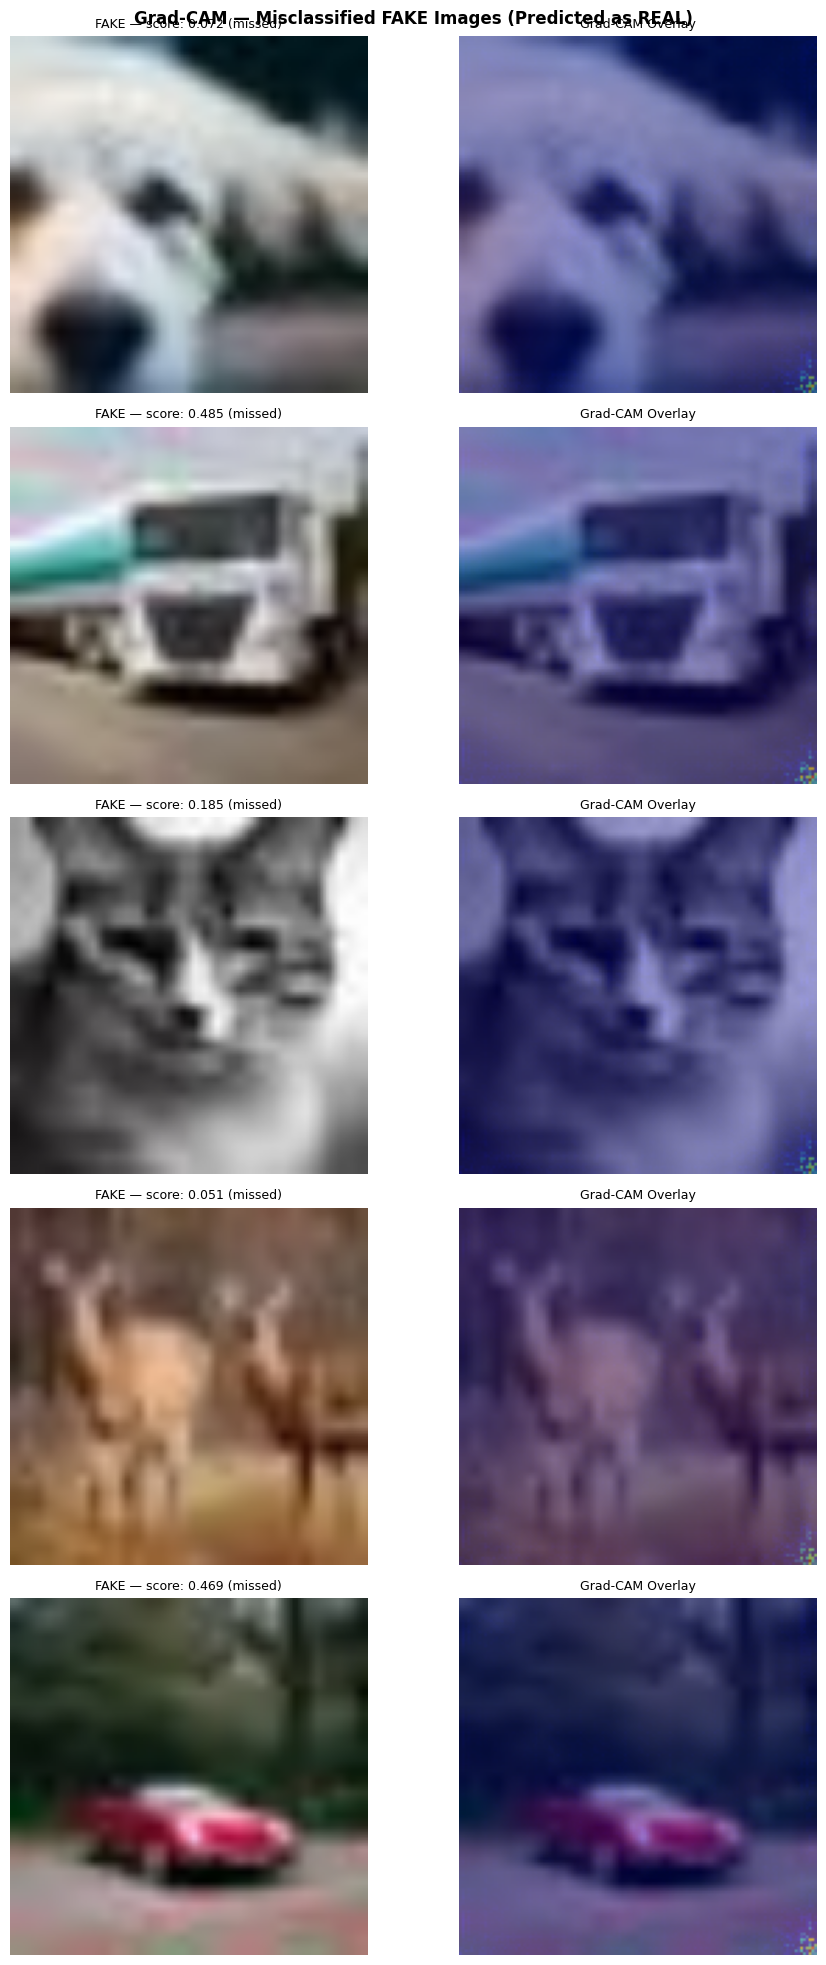

Saved: gradcam_misclassified_fakes.png


In [11]:
if misclassified:
    fig, axes = plt.subplots(len(misclassified), 2,
                              figsize=(10, 4 * len(misclassified)))
    axes = np.atleast_2d(axes)
    fig.suptitle("Grad-CAM — Misclassified FAKE Images (Predicted as REAL)",
                 fontsize=12, fontweight="bold")

    for row, (path, score) in enumerate(misclassified):
        try:
            img_display, rgb_in, dct_in = load_and_prepare(path)
            heatmap, _  = compute_gradcam(dual_model, conv_extractor, rgb_in, dct_in)
            overlay     = overlay_heatmap(img_display, heatmap)

            axes[row, 0].imshow(img_display)
            axes[row, 0].set_title(f"FAKE — score: {score:.3f} (missed)", fontsize=9)
            axes[row, 0].axis("off")

            axes[row, 1].imshow(overlay)
            axes[row, 1].set_title("Grad-CAM Overlay", fontsize=9)
            axes[row, 1].axis("off")

        except Exception as e:
            print(f"Row {row} failed: {e}")
            axes[row, 0].axis("off")
            axes[row, 1].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, "gradcam_misclassified_fakes.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: gradcam_misclassified_fakes.png")
else:
    print("No misclassified fakes found in the sampled set.")


---
## Phase 11 Complete

Grad-CAM heatmaps have been generated and saved for:
- Correctly classified REAL images
- Correctly classified FAKE images
- Misclassified FAKE images (false negatives)

These visualizations directly fulfil the XAI and forensic interpretability requirements of the project proposal.

**Next → Phase 12: Streamlit Deployment**


## Download Phase 11 Outputs

Run this cell after all Grad-CAM visualizations are generated.

In [12]:
import shutil, os

OUTPUT_FILES = [
    "/kaggle/working/results/gradcam/gradcam_real_images.png",
    "/kaggle/working/results/gradcam/gradcam_fake_images.png",
    "/kaggle/working/results/gradcam/gradcam_misclassified_fakes.png",
]

shutil.make_archive("/kaggle/working/phase_11_outputs", "zip", "/kaggle/working/results/gradcam")

print("Files packaged:")
for f in OUTPUT_FILES:
    exists = os.path.exists(f)
    size   = round(os.path.getsize(f) / 1024, 1) if exists else 0
    if exists:
        status = "OK"
    elif "misclassified" in f:
        status = "SKIPPED (no misclassified samples found)"
    else:
        status = "MISSING"
    print(f"  {status:<42} {os.path.basename(f):<45} {size} KB")

print()
print("Download: /kaggle/working/phase_11_outputs.zip")


Files packaged:
  OK                                         gradcam_real_images.png                       424.8 KB
  OK                                         gradcam_fake_images.png                       407.4 KB
  OK                                         gradcam_misclassified_fakes.png               414.3 KB

Download: /kaggle/working/phase_11_outputs.zip
